# Zomato EDA Assignment
This notebook covers all required tasks.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Part 1 - Exploration

In [24]:
df=pd.read_csv('zomato.csv')
print('-------------------------------')
print('Dataset Shape :')
print('---------------')
print(df.shape)
print('-------------------------------')
print('Dataset Column:')
print('---------------')
print(df.columns)
print('-------------------------------')
print('Dataset Type:')
print('---------------')
print(df.dtypes)
print('-------------------------------')
print('Missing values:')
print('---------------')
print(df.isnull().sum())
print('-------------------------------')
print('Duplicates:')
print('---------------')
print(df.duplicated().sum())
print('-------------------------------')
print('Statistical Analysis:')
print('---------------')
df['Average Cost for two']=pd.to_numeric(df['Average Cost for two'],errors='coerce')
display(df.describe(include='all'))
print('-------------------------------')
print('Unique cities')
print('---------------')
print(df['City'].nunique())
print('-------------------------------')
print(df['City'].value_counts().head(10))
print('-------------------------------')
# City with the highest number of restaurants
top_city = df['City'].value_counts().idxmax()
restaurant_count = df['City'].value_counts().max()

print(f"\nCity with the highest number of restaurants: {top_city}")
print(f"Number of restaurants: {restaurant_count}")
print('-------------------------------')
print('Most common cuisine:',df['Cuisines'].mode()[0])

-------------------------------
Dataset Shape :
---------------
(66, 10)
-------------------------------
Dataset Column:
---------------
Index(['Restaurant Name', 'City', 'Cuisines', 'Average Cost for two',
       'Has Online delivery', 'Has Table booking', 'Price range',
       'Aggregate rating', 'Rating text', 'Votes'],
      dtype='object')
-------------------------------
Dataset Type:
---------------
Restaurant Name          object
City                     object
Cuisines                 object
Average Cost for two      int64
Has Online delivery      object
Has Table booking        object
Price range               int64
Aggregate rating        float64
Rating text              object
Votes                     int64
dtype: object
-------------------------------
Missing values:
---------------
Restaurant Name         0
City                    0
Cuisines                0
Average Cost for two    0
Has Online delivery     0
Has Table booking       0
Price range             0
Aggregate r

,Restaurant Name,City,Cuisines,Average Cost for two,Has Online delivery,Has Table booking,Price range,Aggregate rating,Rating text,Votes
count,66,66,66,66.000000,66,66,66.000000,66.000000,66,66.000000
unique,66,11,15,NaN,2,2,NaN,NaN,4,NaN
top,Spice Garden,Bangalore,Cafe,NaN,Yes,Yes,NaN,NaN,Very Good,NaN
freq,1,11,11,NaN,52,34,NaN,NaN,32,NaN
mean,NaN,NaN,NaN,964.393939,NaN,NaN,2.787879,4.315152,NaN,533.787879
std,NaN,NaN,NaN,465.069486,NaN,NaN,1.045358,0.269611,NaN,349.759325
min,NaN,NaN,NaN,300.000000,NaN,NaN,1.000000,3.700000,NaN,120.000000
25%,NaN,NaN,NaN,600.000000,NaN,NaN,2.000000,4.100000,NaN,260.000000
50%,NaN,NaN,NaN,900.000000,NaN,NaN,3.000000,4.300000,NaN,415.000000
75%,NaN,NaN,NaN,1237.500000,NaN,NaN,4.000000,4.500000,NaN,760.000000


-------------------------------
Unique cities
---------------
11
-------------------------------
City
Bangalore    11
Delhi        10
Mumbai        9
Hyderabad     8
Chennai       7
Pune          6
Kochi         5
Kolkata       4
Goa           3
Ahmedabad     2
Name: count, dtype: int64
-------------------------------

City with the highest number of restaurants: Bangalore
Number of restaurants: 11
-------------------------------
Most common cuisine: Cafe


## Part 2 - Analysis

In [32]:
print('Average rating')
print('---------------')
print(df['Aggregate rating'].mean())
print('-------------------------------')
print('Restaurant with the highest number of votes:')
print('---------------')
print(df.loc[df['Votes'].idxmax()])
print('-------------------------------')
print('Average cost')
print('---------------')
print(df['Average Cost for two'].mean())
print('-------------------------------')
# Average Rating by Online Delivery
online_delivery = (
    df.groupby("Has Online delivery")["Aggregate rating"]
      .mean()
      .round(2)
      .reset_index()
      .rename(columns={
          "Has Online delivery": "Online Delivery",
          "Aggregate rating": "Average Rating"
      })
)

print("Average Rating by Online Delivery")
display(online_delivery)
print('-------------------------------')

# Average Rating by Table Booking
table_booking = (
    df.groupby("Has Table booking")["Aggregate rating"]
      .mean()
      .round(2)
      .reset_index()
      .rename(columns={
          "Has Table booking": "Table Booking",
          "Aggregate rating": "Average Rating"
      })
)

print("Average Rating by Table Booking")
display(table_booking)
print('-------------------------------')
print('Top 10 cities with the highest number of restaurants.')
print('---------------')
top_cities=df['City'].value_counts().head(10)
print(top_cities)
print('-------------------------------')

Average rating
---------------
4.315151515151515
-------------------------------
Restaurant with the highest number of votes:
---------------
Restaurant Name         Hyderabadi Dum
City                         Hyderabad
Cuisines                       Biryani
Average Cost for two              1050
Has Online delivery                Yes
Has Table booking                  Yes
Price range                          4
Aggregate rating                   4.8
Rating text                  Excellent
Votes                             1680
Name: 64, dtype: object
-------------------------------
Average cost
---------------
964.3939393939394
-------------------------------
Average Rating by Online Delivery


,Online Delivery,Average Rating
0,No,4.22
1,Yes,4.34


-------------------------------
Average Rating by Table Booking


,Table Booking,Average Rating
0,No,4.09
1,Yes,4.52


-------------------------------
Top 10 cities with the highest number of restaurants.
---------------
City
Bangalore    11
Delhi        10
Mumbai        9
Hyderabad     8
Chennai       7
Pune          6
Kochi         5
Kolkata       4
Goa           3
Ahmedabad     2
Name: count, dtype: int64
-------------------------------


## Part 3 - Visualizations

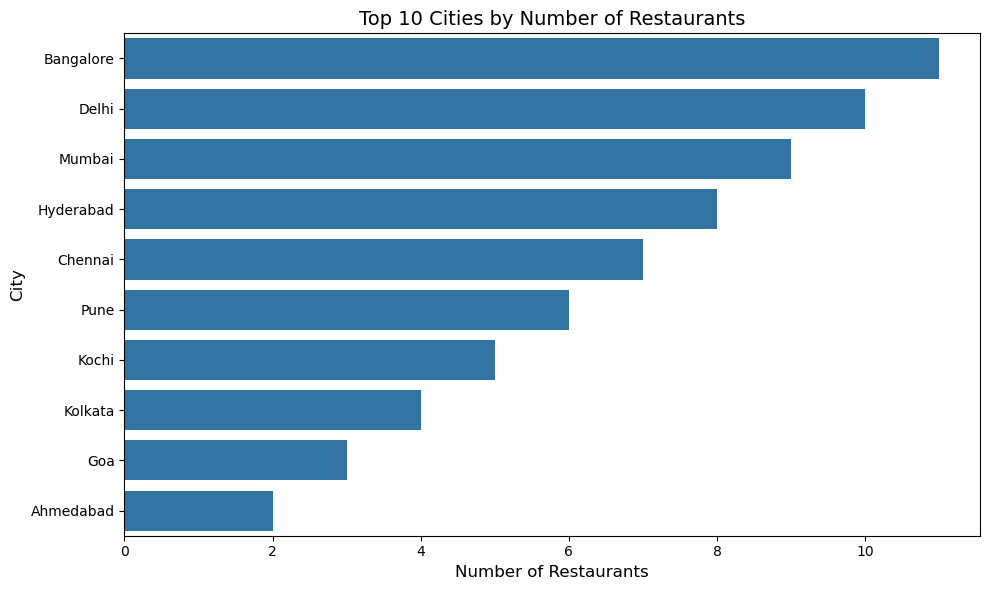

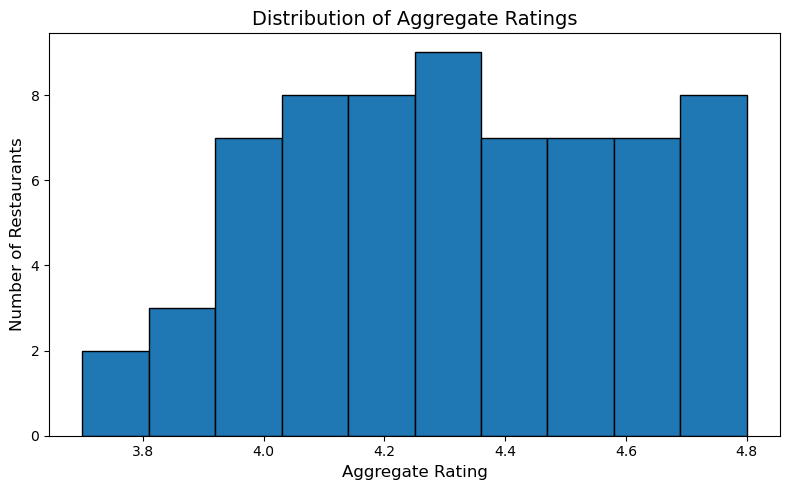

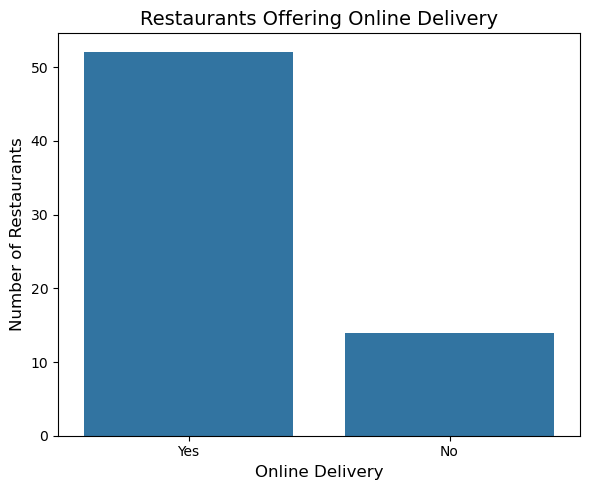

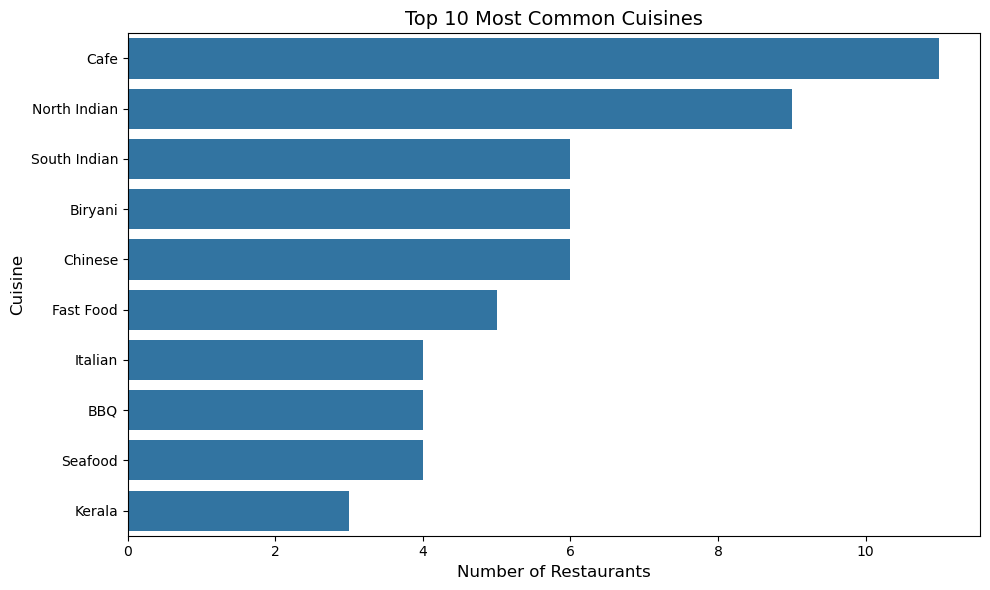

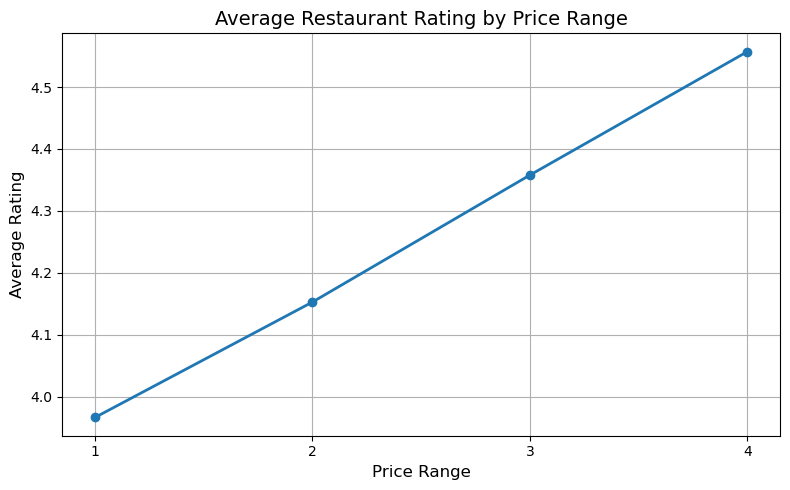

In [29]:
# Bar Chart – Top 10 Cities with Highest Number of Restaurants
plt.figure(figsize=(10,6))

sns.barplot(x=top_cities.values, y=top_cities.index)

plt.title("Top 10 Cities by Number of Restaurants", fontsize=14)
plt.xlabel("Number of Restaurants", fontsize=12)
plt.ylabel("City", fontsize=12)

plt.tight_layout()
plt.show()

# Histogram – Distribution of Aggregate Ratings
plt.figure(figsize=(8,5))

plt.hist(df["Aggregate rating"],
         bins=10,
         edgecolor="black")

plt.title("Distribution of Aggregate Ratings", fontsize=14)
plt.xlabel("Aggregate Rating", fontsize=12)
plt.ylabel("Number of Restaurants", fontsize=12)

plt.tight_layout()
plt.show()

# Bar Chart – Restaurants Offering Online Delivery

plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Has Online delivery")

plt.title("Restaurants Offering Online Delivery", fontsize=14)
plt.xlabel("Online Delivery", fontsize=12)
plt.ylabel("Number of Restaurants", fontsize=12)

plt.tight_layout()
plt.show()

# Bar Chart – Top 10 Most Common Cuisines

top_cuisines = df["Cuisines"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_cuisines.values,
            y=top_cuisines.index)

plt.title("Top 10 Most Common Cuisines", fontsize=14)
plt.xlabel("Number of Restaurants", fontsize=12)
plt.ylabel("Cuisine", fontsize=12)

plt.tight_layout()
plt.show()

# Line Chart – Average Restaurant Rating by Price Range

price_rating = df.groupby("Price range")["Aggregate rating"].mean()

plt.figure(figsize=(8,5))

plt.plot(price_rating.index,
         price_rating.values,
         marker='o',
         linewidth=2)

plt.title("Average Restaurant Rating by Price Range", fontsize=14)
plt.xlabel("Price Range", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)

plt.xticks(price_rating.index)
plt.grid(True)

plt.tight_layout()
plt.show()

# Part 4 – Insights & Conclusion

## 1. Which city has the highest restaurant presence?

**Answer:**

Bangalore has the highest restaurant presence in the dataset, with **11 restaurants**. This indicates that Bangalore has the largest concentration of restaurants among the cities included in this dataset.

---

## 2. What is the most popular cuisine?

**Answer:**

**Cafe** is the most popular cuisine in the dataset, with **11 restaurants** serving it. This suggests that cafe-style restaurants are the most common among the listed establishments.

---

## 3. Do restaurants with Online Delivery generally have higher ratings?

**Answer:**

Yes. Based on the analysis, restaurants that offer **Online Delivery** generally have higher average ratings than those that do not. This indicates that online delivery services may contribute to improved customer satisfaction and convenience.

---

## 4. Do restaurants offering Table Booking receive better ratings?

**Answer:**

Yes. Restaurants offering **Table Booking** have a higher average rating (**4.52**) compared to restaurants without table booking (**4.09**). This suggests that restaurants providing table booking tend to offer a better overall dining experience.

---

## 5. What did you learn from analyzing this dataset?

**Answer:**

From this analysis, the following key insights were observed:

- Bangalore has the highest restaurant presence, with 11 restaurants in the dataset.
- Cafe is the most popular cuisine, also appearing in 11 restaurants.
- Restaurants offering **Online Delivery** generally receive better customer ratings.
- Restaurants that provide **Table Booking** have higher average ratings (4.52) than those that do not (4.09).
- Exploratory Data Analysis (EDA) helps identify restaurant trends, customer preferences, and the impact of restaurant services on customer ratings, enabling businesses to make data-driven decisions. dataset?